In [1]:
%pip install -e ..

Note: you may need to restart the kernel to use updated packages.Obtaining file:///C:/Users/jaspe/Documents/CLS/Thesis/research_core
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for research-core (pyproject.toml): started
  Building editable for research-core (pyproject.toml): finished with status 'done'
  Created wheel for research-core: filename=research_core-0.1.0-0.editable-py3-none-any.whl size=7229 sha256=c40e353c710183a9000b7e3f9394bf5b53a700d9073265312fbb23a165ec7336
  Stored in directory: C:\Users\jaspe\AppData\Loc

DEPRECATION: pytorch-lightning 1.7.7 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [2]:
from pathlib import Path
from research_core.classes import AnalyseMarket, helpers

# ─────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────

ROOT = Path.cwd().resolve().parent
OUTPUT_DIR = ROOT / "data"

asset = "KGHM"
TICK_SIZE = 0.05

# ─────────────────────────────────────────────────────────────
# For REAL MARKET DATA (empirical order-flow database)
# ─────────────────────────────────────────────────────────────
db_path = OUTPUT_DIR / "KGHM_order_flow.sqlite"

am = AnalyseMarket(db_path, tick_size=TICK_SIZE)

# ─────────────────────────────────────────────────────────────
# For SIMULATION DATA, use the simulation database instead:
#   am = AnalyseMarket("sim_events.sqlite", tick_size=0.01)
# ─────────────────────────────────────────────────────────────

AnalyseMarket | KGHM_order_flow.sqlite | real data
  Tables: ['fills', 'mo_orders', 'orders']


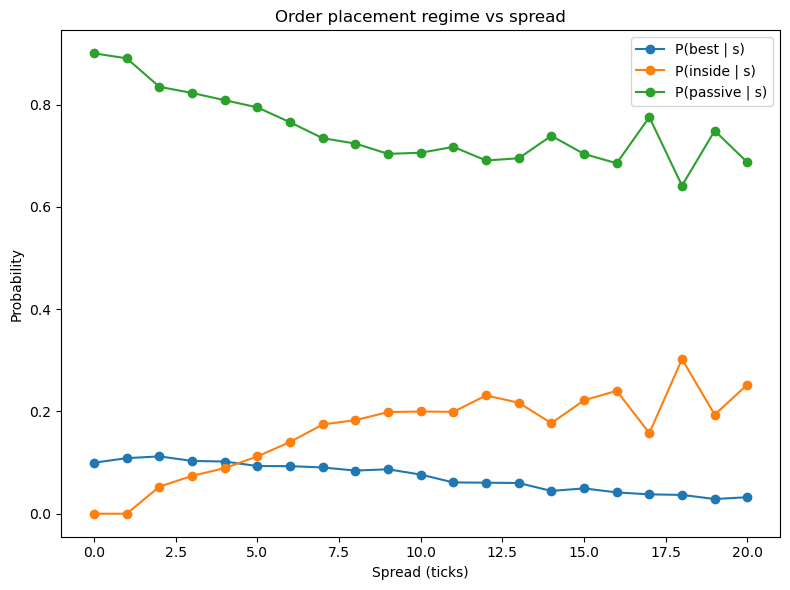

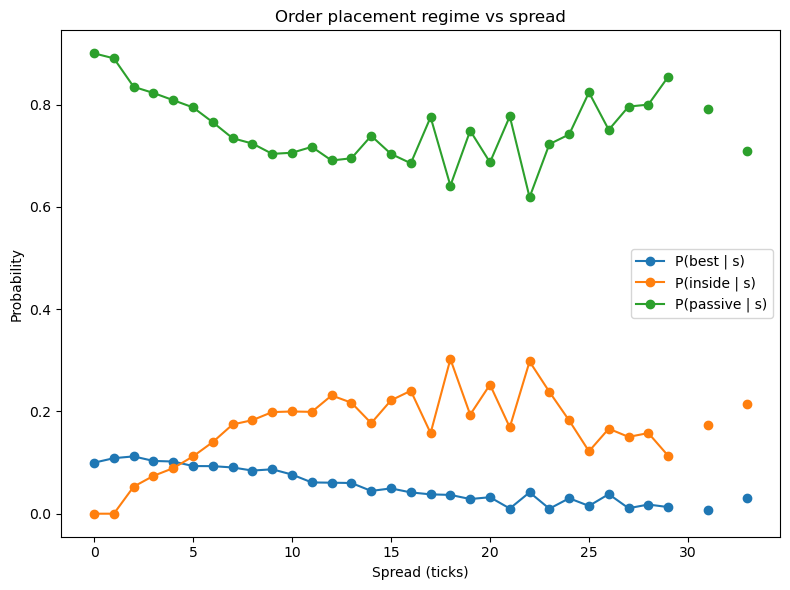

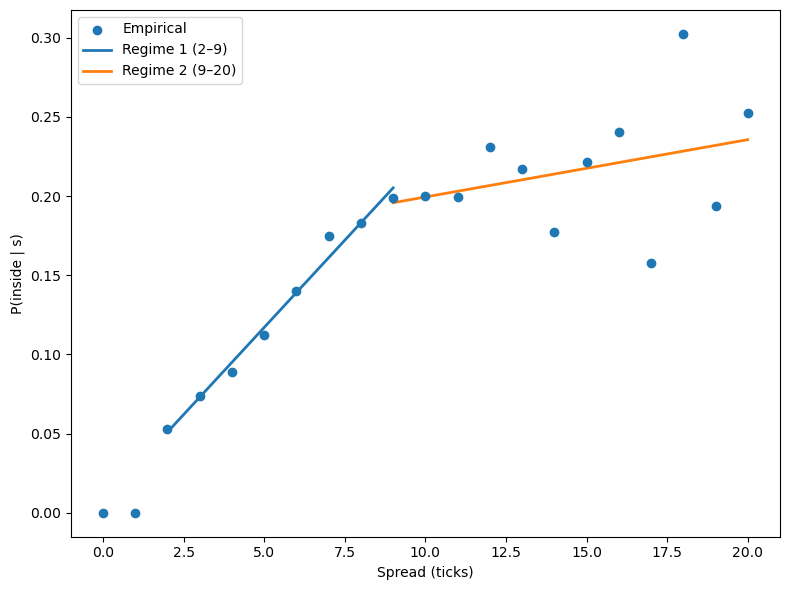

Regime 1 (2–9):   slope=0.022021, intercept=0.006944
Regime 2 (9–20): slope=0.003620, intercept=0.163207


(array([0.02202119, 0.00694422]), array([0.00361973, 0.16320662]))

In [3]:
spread_values, p_best, p_inside, p_passive = am.probability_vs_spread(max_spread=20)
am.piecewise_inside_fit()

## LO regime conditional on spread and signal

Spread sets the baseline best / inside / passive mix (`probability_vs_spread` above). The simulator then tilts aggressive placement via `_resil_multiplier`, which is **rate-preserving**: at a given market state the two sides get `1 ± tanh(ζ)` with `ζ = κ·clip(d) − φ·clip(s)` (ask frame; bid frame is `−ζ`), so the *total* aggressive rate is unchanged and only the **side composition** shifts. The mechanism is therefore a purely **antisymmetric** (between-side) prediction, and it must be tested as such — a per-side regression of P(best+inside) on the own-side signal conflates it with a **common-mode** response (both sides quoting more/less aggressively together after a move, which is expected: replenishment *or* trend continuation both push aggression up on either side).

**`signal_conditional_lo_regime`** isolates the two:

- `mech` — FM slope on the own-side favorability `w = e·ζ` from `aggr ~ 1 + e + ζ + w` (the antisymmetric tilt; the sim predicts **`mech > 0`**);
- `common` — FM slope on `ζ` (the both-sides co-movement, reported separately);
- `D(ζ) = P(aggr | ask, ζ) − P(aggr | bid, ζ)` at **matched `ζ`**, whose slope is `2·mech` and which cancels the common mode — the cleanest dose-response of the tilt (should rise through 0).

A placebo time shift should flatten `D` and drive `mech` (and the contemporaneous `common`) toward 0.

Loading 50 day(s) of LO/BBO data (single scan of KGHM_order_flow.sqlite) ...
  50 days, 5,397,863 BBO points, 2,725,947 LOs


C:\Users\jaspe\Documents\CLS\Thesis\research_core\classes\analyse.py:4428: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(stat, axis=0)
c:\Users\jaspe\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\jaspe\Documents\CLS\Thesis\research_core\classes\analyse.py:5322: RuntimeWarning: Mean of empty slice
  zlo = np.nanmean(p_aggr[si, bi, 0])
C:\Users\jaspe\Documents\CLS\Thesis\research_core\classes\analyse.py:5323: RuntimeWarning: Mean of empty slice
  zhi = np.nanmean(p_aggr[si, bi, -1])



50 days, 2,700,904 LOs | τ=4.5s τ_f=32.3s κ=0.0817 φ=0.0746

 side     band    slope      t P_aggr|z_lo P_aggr|z_hi Δ vs marg
  bid      s=2   0.0585    5.7      0.1195      0.1314   -0.0188
  bid    s=3–5  -0.0094   -0.8      0.1598      0.1564   -0.0223
  bid    s=6–9   0.0971    1.6      0.2439      0.2589   -0.0025
  bid  s=10–20  -0.0693   -0.5         nan         nan       nan
  ask      s=2  -0.0558   -3.9      0.1396      0.1207   -0.0295
  ask    s=3–5  -0.0285   -2.4      0.1763      0.1663   -0.0124
  ask    s=6–9  -0.0564   -1.8      0.2399      0.2450   -0.0165
  ask  s=10–20   0.0025    0.0         nan         nan       nan


c:\Users\jaspe\anaconda3\lib\site-packages\matplotlib\axes\_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\jaspe\anaconda3\lib\site-packages\matplotlib\axes\_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


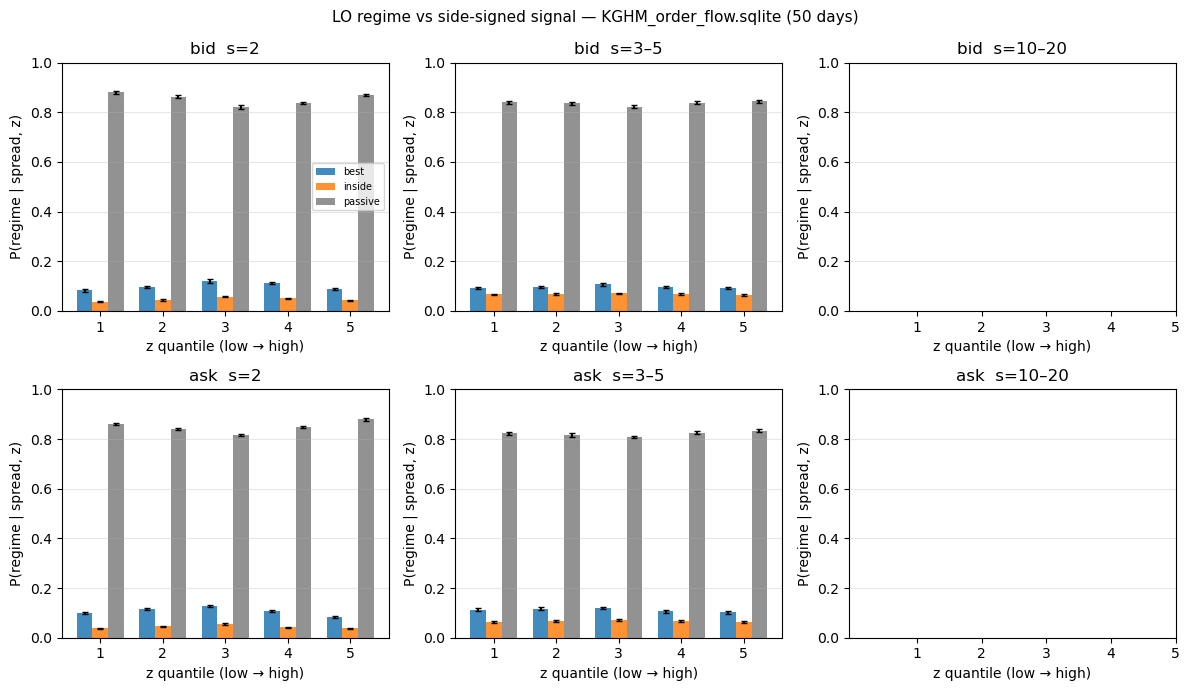

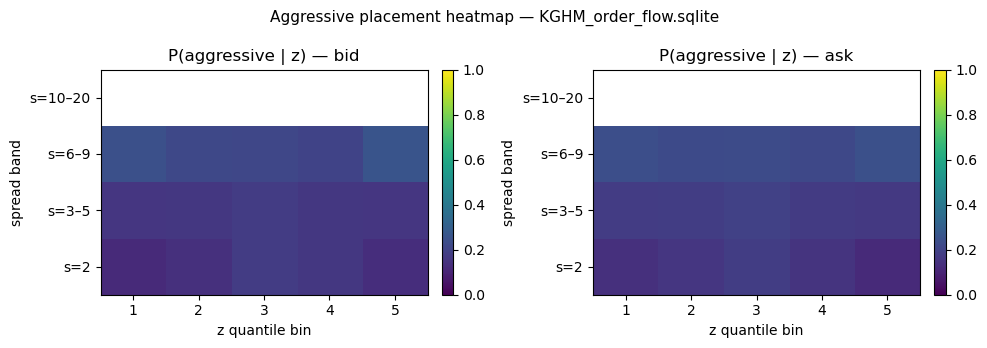

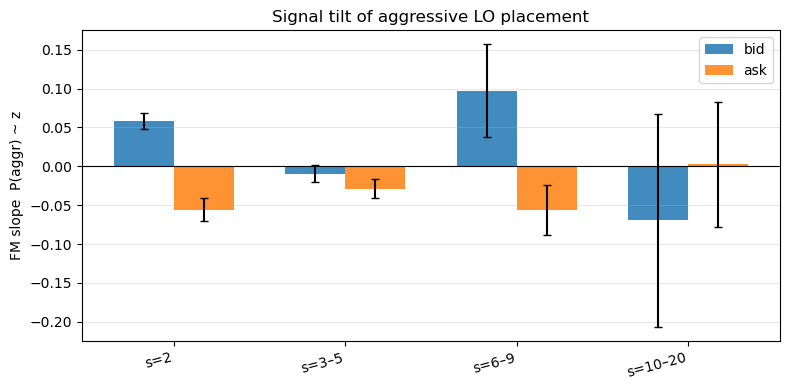

In [4]:
lo_regime = am.signal_conditional_lo_regime(n_days=50)


50 days, 2,700,904 LOs | τ=4.5s τ_f=32.3s κ=0.0817 φ=0.0746  [PLACEBO: signal shifted 300s back]

 side     band    slope      t P_aggr|z_lo P_aggr|z_hi Δ vs marg
  bid      s=2  -0.0358   -1.4      0.1421      0.1387   -0.0115
  bid    s=3–5  -0.0168   -0.9      0.1648      0.1588   -0.0200
  bid    s=6–9  -0.0635   -0.4      0.2166      0.2527   -0.0088
  bid  s=10–20  -2.2024   -1.0         nan      0.5624    0.0784
  ask      s=2  -0.0262   -2.4      0.1488      0.1445   -0.0057
  ask    s=3–5  -0.0115   -0.7      0.1766      0.1759   -0.0028
  ask    s=6–9   0.1342    1.2      0.2325      0.2326   -0.0289
  ask  s=10–20  -0.0151   -0.0         nan      0.4675   -0.0164


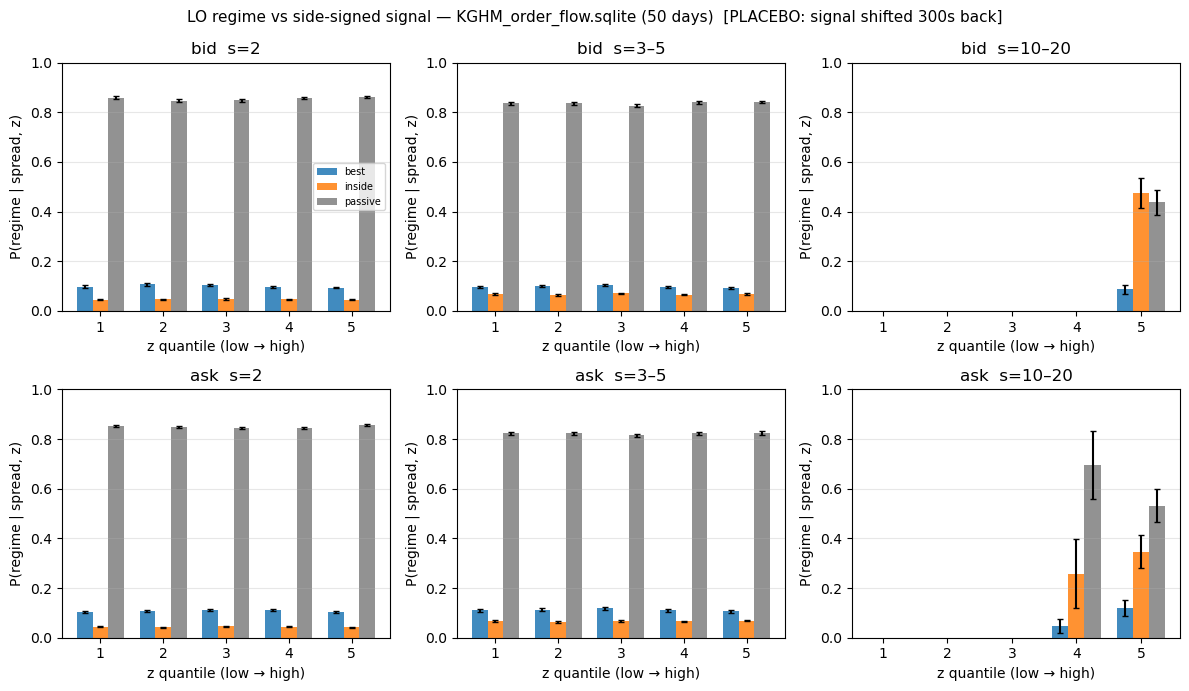

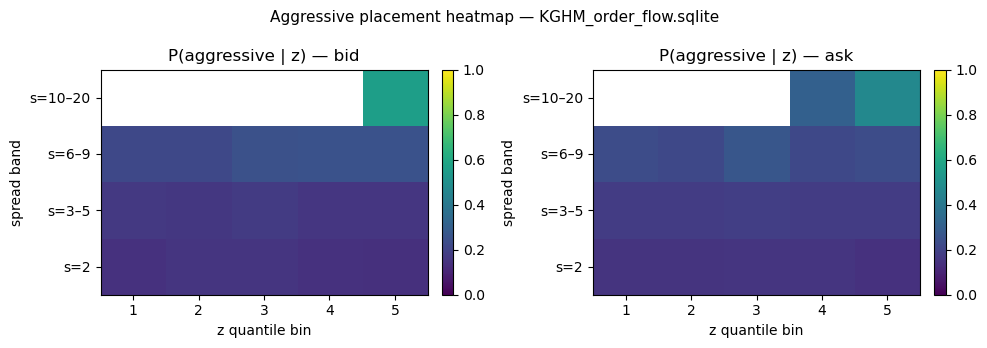

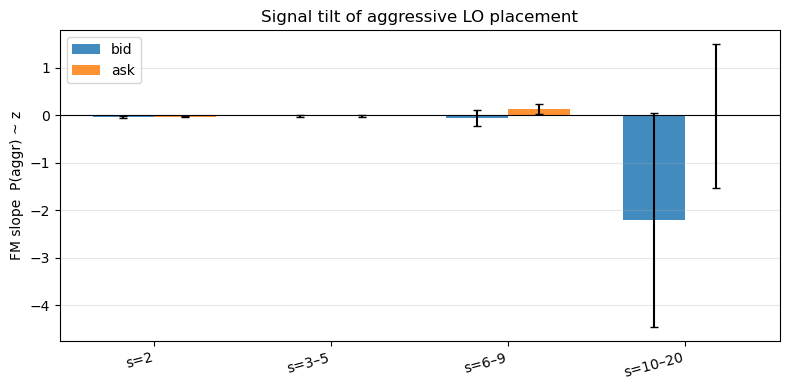

In [5]:
lo_regime_placebo = am.signal_conditional_lo_regime(n_days=50, signal_shift_s=300.0)

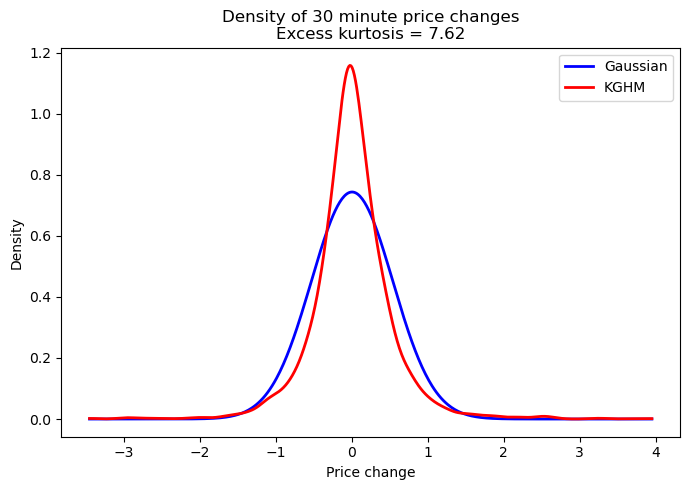

Interval: 30 min  |  n_changes: 3916  |  changes='level'  |  Excess kurtosis: 7.62


In [6]:
am.stylized_fat_tails(label="KGHM")

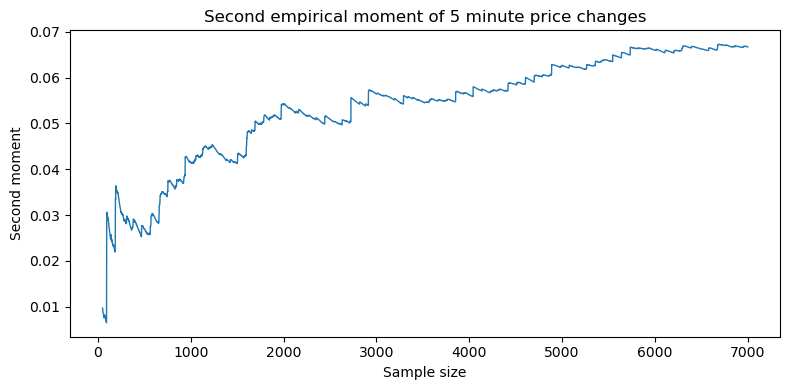

Interval: 5 min  |  n_changes: 23498  |  Final M₂: 0.050843


In [7]:
am.stylized_moment_instability()

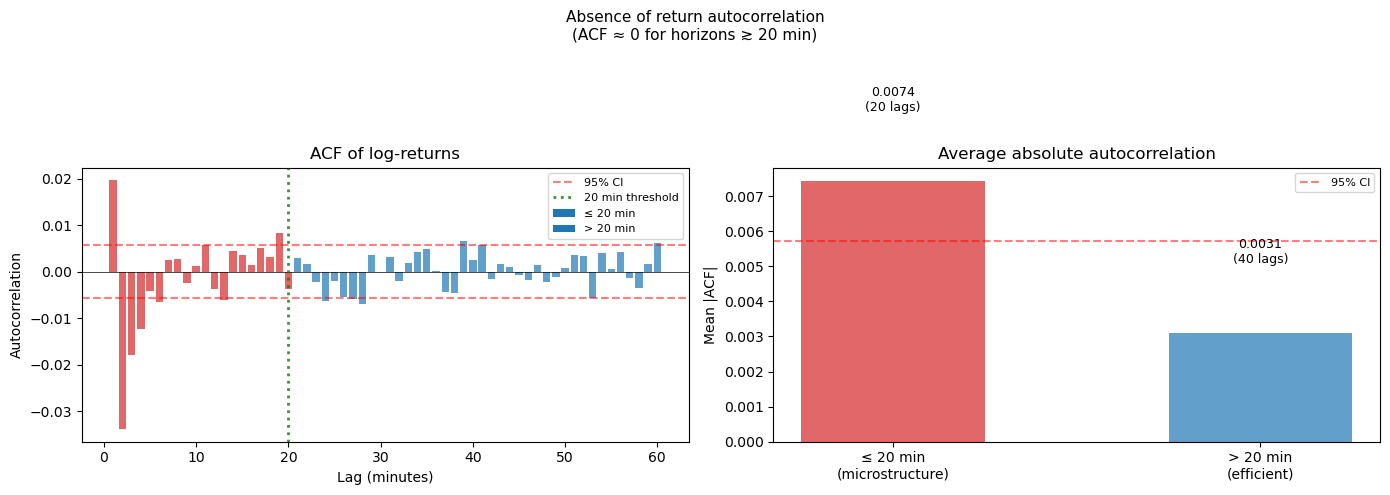

Sampling interval: 1 min
Mean |ACF| ≤ 20 min: 0.0074  (20 lags)
Mean |ACF| > 20 min: 0.0031  (40 lags)


In [8]:
am.stylized_return_autocorrelation()

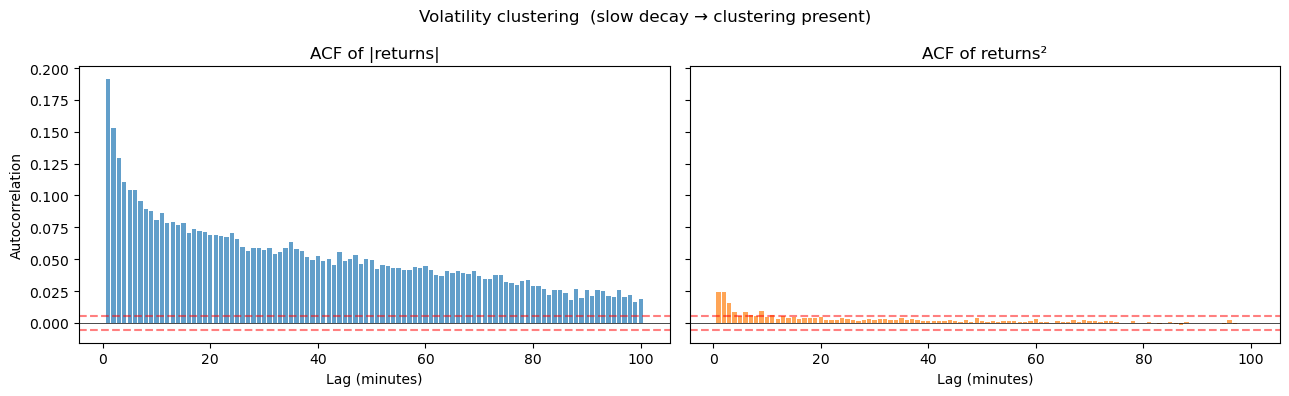

|returns| ACF half-life ≈ 16 min
|returns| ACF(1 min) = 0.1915,  ACF(10 min) = 0.0807


In [9]:
am.stylized_volatility_clustering()

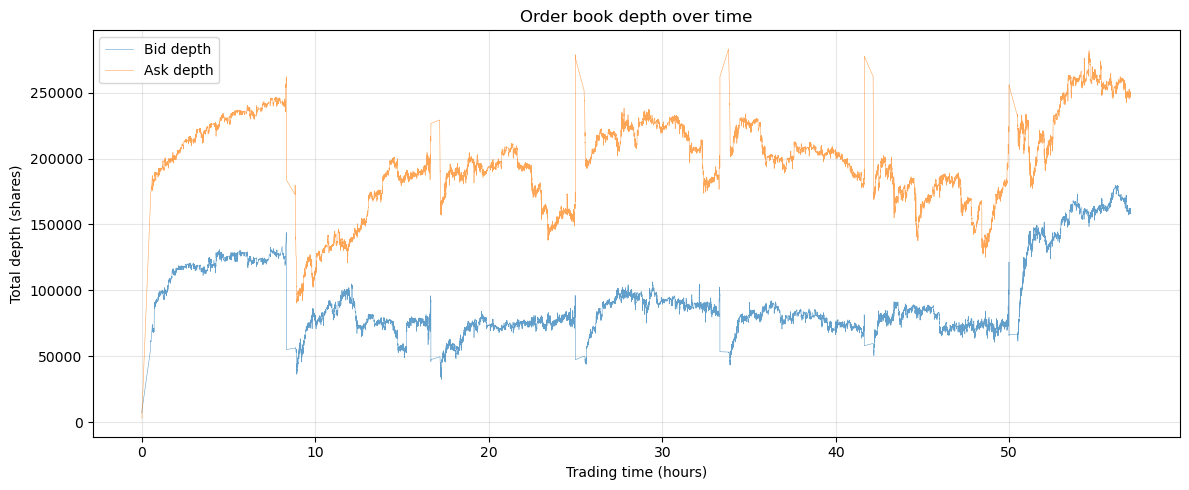

In [10]:
am.plot_depth(n_events=1_000_000, offset=0)

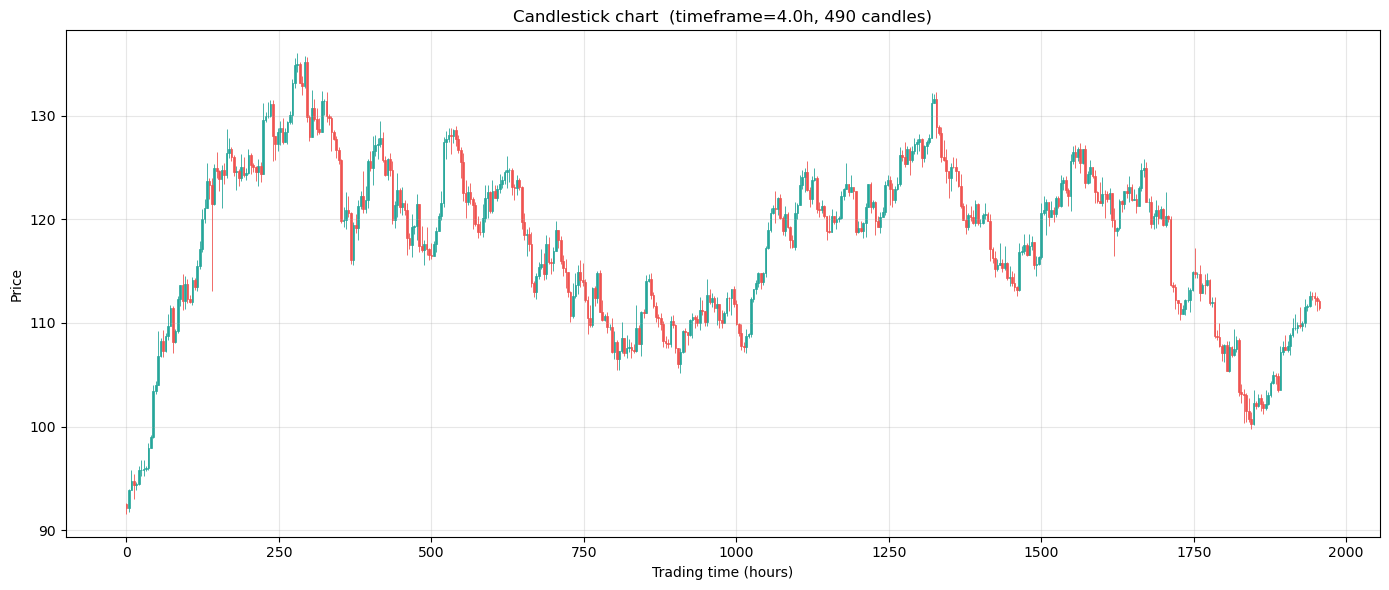

In [11]:
am.plot_candlestick(timeframe=14400.0)

Full sign series length: 661,230 MOs,  buy fraction: 0.513
Power-law exponent:  γ = 0.5285   (ρ(k) ~ k^{-0.5285})


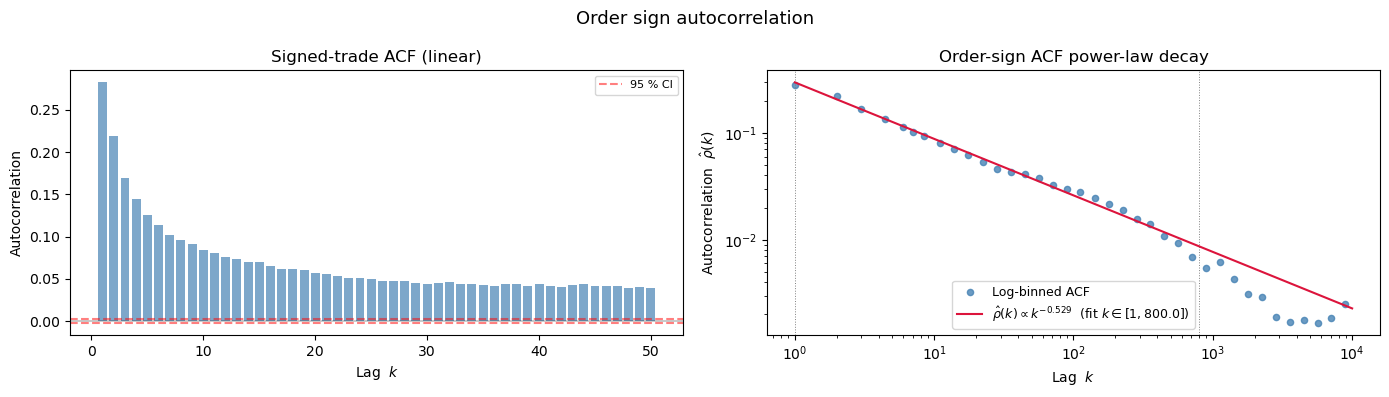

In [12]:
am.stylized_order_sign_autocorrelation(cap=800)

## Mean-reversion signature & signal-conditioned MO reaction

**`signature_plot`** — normalized signature / variance-ratio curve $\mathrm{VR}(\tau) = C(\tau)/C(1\,\mathrm{s})$, one curve per trading day (or per 7.8 h session for simulation DBs), averaged with ±1 SE bands. $\mathrm{VR} < 1$ = mean reversion, $> 1$ = momentum. Same methodology as `mean_reversion_evidence.ipynb` / the calibration target.

**`signal_conditional_markout`** — price-level validation of the state-dependent LO-placement mechanism: at each market order, sample the *pre-MO* band-pass displacement $d$ and trend $s$ (the exact signals driving `resil_kappa` / `resil_phi` in the simulator) and measure the signed post-impact markout $y(h) = \varepsilon\,(m(t_0+h) - m_{\text{post}})$. If the mechanism's signal is real in the data:

- slope of $y(h)$ on $\varepsilon d$: **negative** at $h \lesssim 10\text{–}15$ s, washing out to ~0 by 60–120 s (zero-integral band-pass fingerprint);
- slope on $\varepsilon s$: **positive**, growing over $h \sim 20\text{–}120$ s (may be nonlinear — see the dose-response panels);
- MOs the calibrated tilt classifies as "revert" ($\varepsilon\,\zeta > 0$) underperform those classified "continue".

**`signal_pre_move_tick`** — simpler local test: at each ±1-tick mid step, read $d$ and $s$ at the **last event before the move** and regress the signed tick move on $(d, s)$. Expect **$b_d < 0$** (displacement → revert) and **$b_s > 0$** (trend → continue). A small effect is sufficient — the simulator only slightly tilts aggressive LO probability via `1 + tanh(κ·…)`.

**`signal_conditional_lo_regime`** (earlier in this notebook) — tests the sim's *rate-preserving* placement channel directly, decomposing the LO-aggression response into the **antisymmetric tilt** the sim implements (`mech`, the between-side differential `D(ζ)`) versus a **common-mode** co-movement of both sides. This separates the mechanism from the (expected) both-sides reaction to a move.

Statistics are aggregated Fama–MacBeth across days, so within-day serial correlation never inflates the t-stats. These signal methods default to the calibrated parameters in `data/resiliency_calibration.json` and share cached single-scan data panels (the first call scans the 8 GB DB, ~3 min; subsequent calls are then free).

For the sim-vs-empirical comparison, run the identical calls on a simulation DB:

```python
am_sim = AnalyseMarket("sim_resil_0.sqlite", tick_size=TICK_SIZE)
am_sim.signature_plot(compare_to="_cache_signature_multiday_dense_300s.npz")
am_sim.signal_conditional_markout()
am_sim.signal_pre_move_tick()
```

Loading 50 day(s) of mid/MO data (single scan of KGHM_order_flow.sqlite) ...
  50 days, 5,397,863 mid points, 174,968 MOs


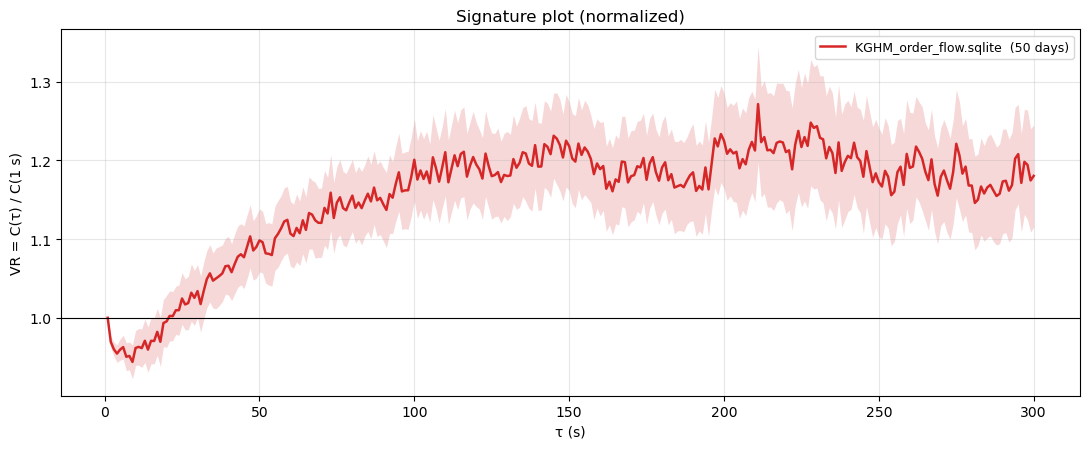

  tau      mean       SE
    3    0.9599   0.0088
    5    0.9595   0.0135
    7    0.9505   0.0177
   10    0.9616   0.0220
   20    0.9953   0.0330
   30    1.0339   0.0336
   50    1.0982   0.0401
   75    1.1462   0.0460
  100    1.2007   0.0520
  150    1.2181   0.0564
  300    1.1802   0.0646
dip min (2-15 s): 0.9439 at τ=9 s


In [13]:
sig = am.signature_plot(n_days=50)


50 days, 171,233 MOs | τ=4.5s τ_f=32.3s κ=0.0817 φ=0.0746 | base=post

  h(s)       b_d      t       b_s      t  | revert  continue     diff      t
     1   -0.0843   -5.8    0.0073    1.3 |  0.3673    0.3852  -0.0179   -1.9
     2   -0.0727   -3.9    0.0158    2.6 |  0.3892    0.4117  -0.0225   -2.0
     3   -0.0689   -3.5    0.0232    2.7 |  0.4049    0.4388  -0.0339   -2.8
     5   -0.0527   -2.6    0.0291    1.6 |  0.4255    0.4799  -0.0544   -4.2
     7   -0.0456   -2.3    0.0352    1.3 |  0.4425    0.5113  -0.0688   -4.4
    10   -0.0397   -1.7    0.0332    0.9 |  0.4660    0.5454  -0.0794   -4.1
    15   -0.0386   -1.2    0.0391    0.8 |  0.4836    0.5971  -0.1135   -3.9
    20   -0.0389   -1.0    0.0553    1.1 |  0.4906    0.6304  -0.1398   -3.8
    30   -0.0145   -0.4    0.0790    1.5 |  0.5174    0.6812  -0.1638   -4.2
    60    0.0324    0.8    0.0939    1.4 |  0.5742    0.7545  -0.1803   -3.3
   120    0.0603    1.1    0.0216    0.2 |  0.6525    0.7654  -0.1128   -1.4


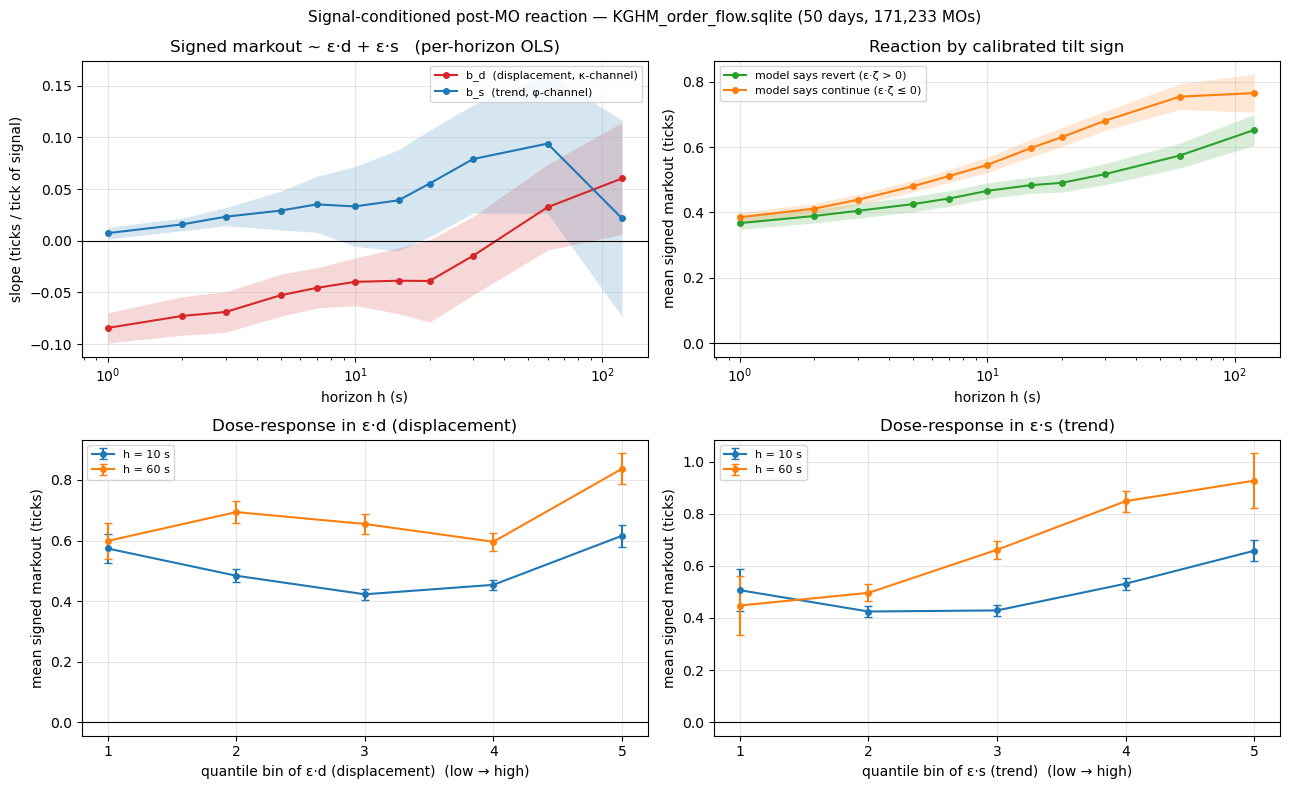

In [14]:
mo_reaction = am.signal_conditional_markout(n_days=50)


50 days, 171,233 MOs | τ=4.5s τ_f=32.3s κ=0.0817 φ=0.0746 | base=post  [PLACEBO: signal shifted 300s back]

  h(s)       b_d      t       b_s      t  | revert  continue     diff      t
     1   -0.0072   -0.6   -0.0152   -2.9 |  0.3776    0.3764   0.0012    0.1
     2   -0.0021   -0.1   -0.0147   -2.1 |  0.4012    0.4015  -0.0003   -0.0
     3    0.0026    0.2   -0.0154   -2.0 |  0.4217    0.4249  -0.0033   -0.2
     5    0.0121    0.6   -0.0115   -1.2 |  0.4518    0.4584  -0.0066   -0.3
     7    0.0251    1.1   -0.0095   -0.8 |  0.4787    0.4812  -0.0025   -0.1
    10    0.0254    0.9   -0.0070   -0.5 |  0.5052    0.5129  -0.0077   -0.2
    15    0.0492    1.5   -0.0111   -0.6 |  0.5392    0.5520  -0.0129   -0.4
    20    0.0628    1.6   -0.0131   -0.6 |  0.5567    0.5780  -0.0213   -0.6
    30    0.0670    1.4   -0.0200   -0.6 |  0.5948    0.6209  -0.0261   -0.6
    60    0.0946    1.5   -0.0875   -1.7 |  0.6794    0.6702   0.0091    0.1
   120    0.0503    0.5   -0.1881   -2.4 |  

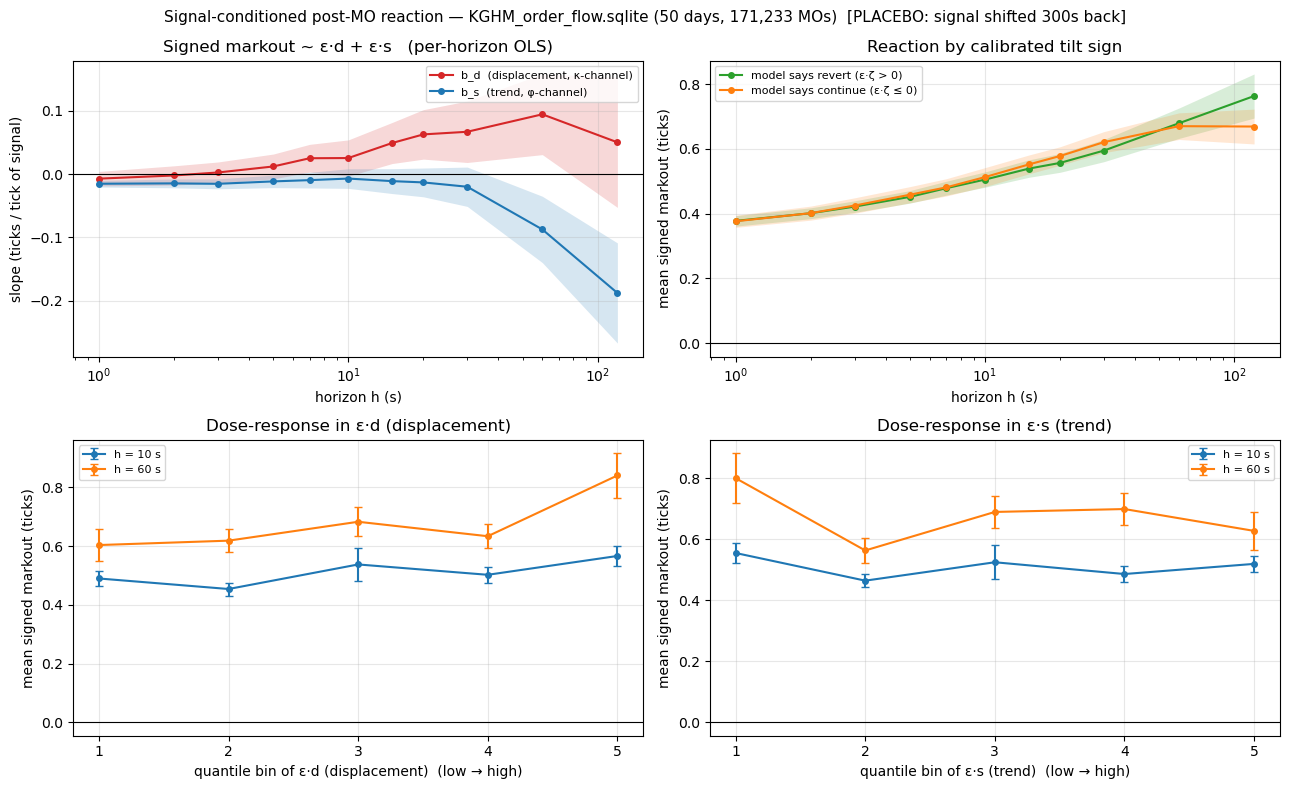

In [15]:
# Placebo: sample the signal 300 s before each MO — the conditioning must collapse.
placebo = am.signal_conditional_markout(n_days=50, signal_shift_s=300.0)


50 days, 103,660 mid moves (±1 tick) | τ=4.5s τ_f=32.3s κ=0.0817 φ=0.0746

    coef      mean       SE      t
 b_d (d)   -0.2487   0.0203  -12.2
 b_s (s)    0.0092   0.0049    1.9
  revert    0.0162   0.0135 | continue 0.0002  diff 0.0160 (t=0.6)


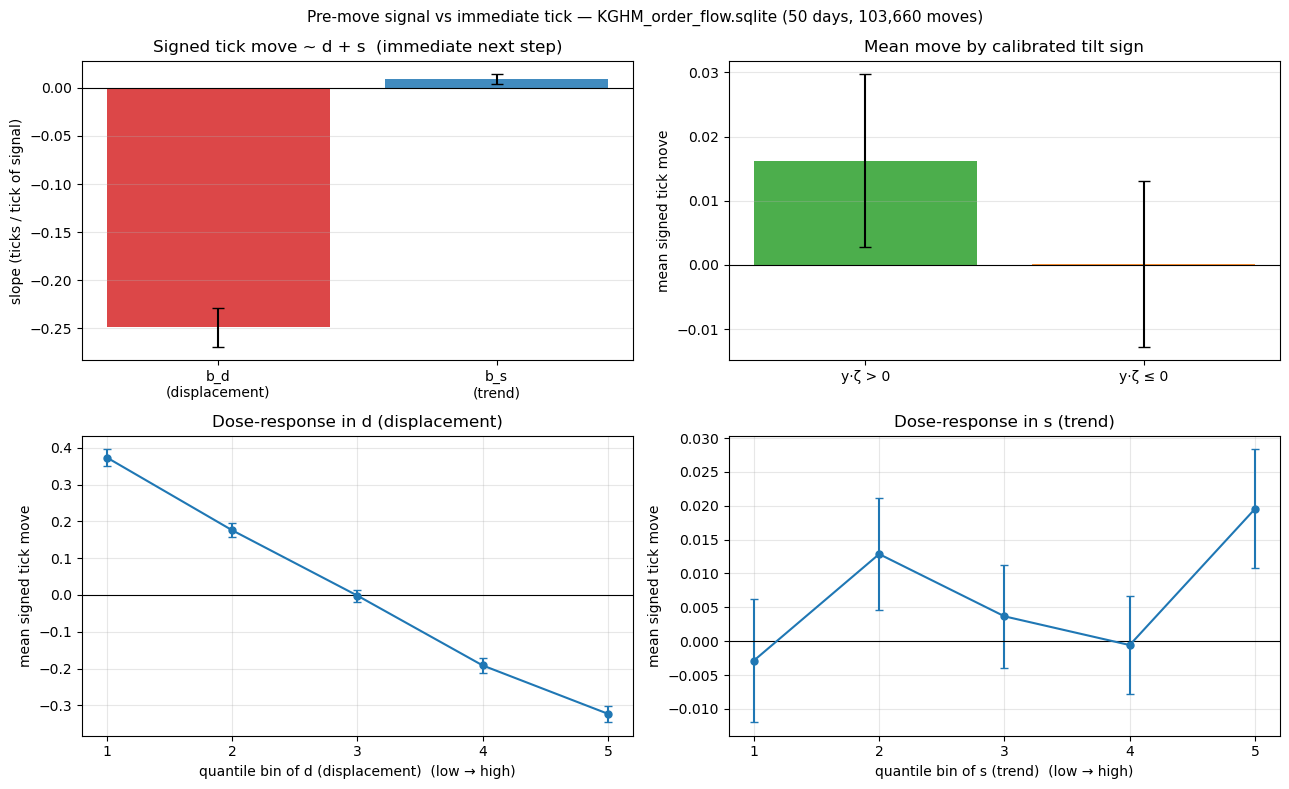

In [16]:
tick_pred = am.signal_pre_move_tick(n_days=50)


50 days, 103,659 mid moves (±1 tick) | τ=4.5s τ_f=32.3s κ=0.0817 φ=0.0746  [PLACEBO: signal shifted 300s back]

    coef      mean       SE      t
 b_d (d)    0.0062   0.0071    0.9
 b_s (s)   -0.0069   0.0043   -1.6
  revert    0.0208   0.0164 | continue -0.0080  diff 0.0288 (t=0.9)


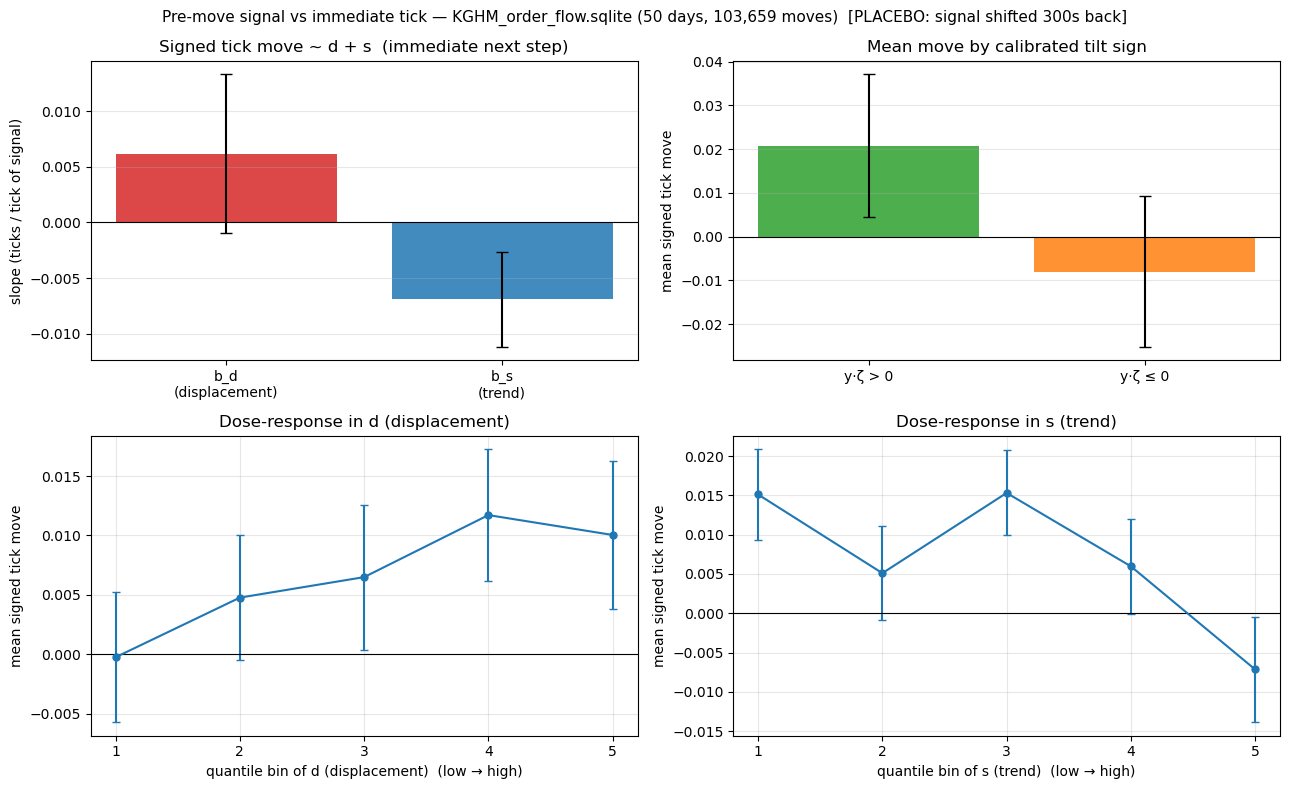

In [17]:
# Placebo: sample the signal 300 s before t[i-1] — conditioning must collapse.
tick_placebo = am.signal_pre_move_tick(n_days=50, signal_shift_s=300.0)